<a href="https://colab.research.google.com/github/adenurchalisa/Automatic-Photo-Clustering-System-Optimization-HDBSCAN/blob/main/notebooks/17_NTCGA_UMAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 17: NT-CGA + UMAP — Recovery Residual Noise Pasca UMAP+HDBSCAN

## Latar Belakang & Motivasi

**Notebook 9 (UMAP+HDBSCAN)** menghasilkan performa terbaik secara keseluruhan:
- **95 cluster**, coverage **99.3%**, silhouette **0.9041**
- Noise hanya **0.7%** ≈ **89 titik** dari 12,715 embeddings

**Notebook 13 (NT-CGA)** berhasil merecovery noise baseline (43.8%) menggunakan augmentasi Gaussian yang diarahkan ke noise points (probable singletons via DNCN):
- Konfigurasi terbaik: coverage **80.5%**, +24.3% dari baseline 56.2%
- Bekerja di ruang 512-dim (embedding asli InsightFace)

**Pertanyaan penelitian:** Apakah NT-CGA dapat merecovery sisa noise 0.7% yang tertinggal setelah UMAP+HDBSCAN?

## Hipotesis

Noise 0.7% pasca UMAP+HDBSCAN memiliki karakteristik yang sangat berbeda dari noise baseline:

| Aspek | Noise Baseline (NB13) | Residual Noise (NB17) |
|-------|----------------------|----------------------|
| Jumlah | 5,565 (43.8%) | ~89 (0.7%) |
| Ruang kerja | 512-dim | 30-dim UMAP |
| Penyebab | Curse of dimensionality | Genuinely ambiguous faces |
| DNCN threshold | 16.98 (Q25 di 512-dim) | Perlu dikalibrasi di 30-dim |

**Hipotesis:** Residual noise pasca UMAP merepresentasikan wajah yang *genuinely* sulit dikelompokkan (oklusi, blur, pose ekstrem, muncul sangat sedikit). NT-CGA mungkin dapat merecovery sebagian kecil, namun dampaknya akan terbatas.

## Alur Eksperimen

```
Embeddings (12,715 x 512) [InsightFace buffalo_l]
        |
        v
UMAP (n_comp=30, n_neigh=30, cosine, min_dist=0.0)
        |
        v
HDBSCAN (mcs=20, ms=20, eom)  [NB9 Best Config]
        |                |_____ 95 cluster, coverage 99.3%
        v
~89 Noise Points (0.7%) di 30-dim UMAP space
        |
        v
DNCN Analysis (kalibrasi threshold di 30-dim)
        |
        v
NT-CGA: Gaussian Augmentation pada Probable Singletons
        |
        v
Re-clustering HDBSCAN (mcs kecil: 2-5)
        |
        v
Evaluasi & Ablation Study (alpha, n_synthetic, mcs_recluster)
```

## Perbedaan Kunci vs NB13

1. **Ruang kerja:** NT-CGA beroperasi di **30-dim UMAP space** (bukan 512-dim)
2. **Skala DNCN:** Jarak di UMAP space berbeda skala, threshold Q25 dikalibrasi ulang
3. **Jumlah target:** ~22 probable singletons (25% dari 89) vs 1,395 di NB13
4. **k_neighbors sigma:** Lebih kecil (k=5) karena data noise sangat sedikit
5. **mcs_recluster:** Sangat kecil (2-5) untuk mendeteksi mikro-cluster dari noise

## Cell 1 — Instalasi & Imports

In [1]:
!pip install umap-learn hdbscan cupy-cuda12x -q

import importlib.metadata
import numpy as np
import pickle
import time
import os
import warnings
from collections import Counter
from datetime import datetime
from itertools import product

import cupy as cp
import umap
import hdbscan
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Cek GPU
gpu_name = cp.cuda.runtime.getDeviceProperties(0)['name'].decode()
gpu_mem  = cp.cuda.runtime.getDeviceProperties(0)['totalGlobalMem'] / (1024**3)
print(f'GPU  : {gpu_name} ({gpu_mem:.1f} GB VRAM)')
print(f'CuPy : {cp.__version__}')
print(f'UMAP : {importlib.metadata.version("umap-learn")}')
print(f'HDBSCAN: {importlib.metadata.version("hdbscan")}')
print('Semua library berhasil dimuat')

GPU  : Tesla T4 (14.6 GB VRAM)
CuPy : 14.0.1
UMAP : 0.5.11
HDBSCAN: 0.8.41
Semua library berhasil dimuat


/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


## Cell 2 — Konfigurasi

Semua hyperparameter dikentralisasi di class `Config`.

**UMAP config** mengikuti NB9 best by coverage: `n_components=30, n_neighbors=30, cosine, min_dist=0.0`.

**Ablation NT-CGA:**
- `alpha` in {0.3, 0.5, 1.0} — scale factor variasi Gaussian
- `n_synthetic` in {5, 10, 15} — sampel sintetis per singleton
- `mcs_recluster` in {2, 3, 5} — min_cluster_size re-clustering (sangat kecil karena residual noise sedikit)

In [2]:
class Config:
    # --- Path ---
    EMBEDDINGS_PATH = '/content/drive/MyDrive/OTW S.KOM/Embeddings/embeddings_data.pkl'
    RESULTS_DIR     = '/content/drive/MyDrive/OTW S.KOM/Results/'
    PLOTS_DIR       = '/content/drive/MyDrive/OTW S.KOM/Results/Plots/'

    # --- UMAP Config (NB9 Best by Coverage) ---
    UMAP_N_COMPONENTS = 30
    UMAP_N_NEIGHBORS  = 30
    UMAP_METRIC       = 'cosine'
    UMAP_MIN_DIST     = 0.0
    UMAP_RANDOM_STATE = 42

    # --- HDBSCAN Config (NB9 Best by Coverage) ---
    HDBSCAN_MCS    = 20
    HDBSCAN_MS     = 20
    HDBSCAN_METHOD = 'eom'

    # --- NT-CGA Config ---
    # k nearest clustered neighbors untuk estimasi sigma_local
    # Lebih kecil dari NB13 (k=10) karena noise jauh lebih sedikit
    K_NEIGHBORS_SIGMA = 5

    # DNCN threshold: Q25 dari distribusi jarak noise ke clustered point
    # (dikalibrasi dari data, tidak di-hardcode seperti NB13)
    DNCN_PERCENTILE = 25

    # --- Ablation Grid ---
    ALPHA_LIST       = [0.3, 0.5, 1.0]
    N_SYNTHETIC_LIST = [5, 10, 15]
    MCS_RECLUSTER    = [2, 3, 5]   # sangat kecil: residual noise ~89 titik
    MS_RECLUSTER     = 1           # ms=1 agar HDBSCAN fleksibel

    SEED = 42

    # Referensi dari NB9
    NB9_REFERENCE = {
        'n_clusters' : 95,
        'coverage'   : 0.993,
        'noise_ratio': 0.007,
        'silhouette' : 0.9041,
    }


cp.random.seed(Config.SEED)
np.random.seed(Config.SEED)

total_ablasi = len(Config.ALPHA_LIST) * len(Config.N_SYNTHETIC_LIST) * len(Config.MCS_RECLUSTER)
print('CONFIG LOADED')
print(f'  UMAP    : n_comp={Config.UMAP_N_COMPONENTS}, n_neigh={Config.UMAP_N_NEIGHBORS}, metric={Config.UMAP_METRIC}')
print(f'  HDBSCAN : mcs={Config.HDBSCAN_MCS}, ms={Config.HDBSCAN_MS}, method={Config.HDBSCAN_METHOD}')
print(f'  NT-CGA  : k_sigma={Config.K_NEIGHBORS_SIGMA}, dncn_pct={Config.DNCN_PERCENTILE}')
print(f'  Ablasi  : alpha={Config.ALPHA_LIST} x n_syn={Config.N_SYNTHETIC_LIST} x mcs={Config.MCS_RECLUSTER}')
print(f'  Total kombinasi: {total_ablasi}')
print(f'\n  Referensi NB9 (UMAP+HDBSCAN best):')
for k, v in Config.NB9_REFERENCE.items():
    print(f'    {k:<12}: {v:.1%}' if isinstance(v, float) and v < 2 else f'    {k:<12}: {v}')

CONFIG LOADED
  UMAP    : n_comp=30, n_neigh=30, metric=cosine
  HDBSCAN : mcs=20, ms=20, method=eom
  NT-CGA  : k_sigma=5, dncn_pct=25
  Ablasi  : alpha=[0.3, 0.5, 1.0] x n_syn=[5, 10, 15] x mcs=[2, 3, 5]
  Total kombinasi: 27

  Referensi NB9 (UMAP+HDBSCAN best):
    n_clusters  : 95
    coverage    : 99.3%
    noise_ratio : 0.7%
    silhouette  : 90.4%


## Cell 3 — Load Data

In [3]:
from google.colab import drive

print('LOAD DATA')

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print('Google Drive sudah ter-mount')

os.makedirs(Config.RESULTS_DIR, exist_ok=True)
os.makedirs(Config.PLOTS_DIR, exist_ok=True)

with open(Config.EMBEDDINGS_PATH, 'rb') as f:
    data = pickle.load(f)

embeddings = np.array(data['embeddings']).astype('float32')
metadata   = data['metadata']

print(f'Embeddings : {embeddings.shape}, dtype={embeddings.dtype}')
print(f'Metadata   : {len(metadata)} entries')

LOAD DATA
Mounted at /content/drive
Embeddings : (12715, 512), dtype=float32
Metadata   : 12715 entries


## Cell 4 — UMAP + HDBSCAN (NB9 Best Config)

Mereproduksi pipeline UMAP+HDBSCAN dari NB9 konfigurasi terbaik:
- **UMAP:** `n_components=30, n_neighbors=30, metric=cosine, min_dist=0.0`
- **HDBSCAN:** `mcs=20, ms=20, method=eom`

Dijalankan di CPU karena `metric='correlation'` yang dipakai NB9 tidak disupport cuML. Namun di 30-dim, HDBSCAN CPU masih sangat cepat.

**Catatan penting:** UMAP menghasilkan ruang 30-dim yang akan menjadi ruang kerja NT-CGA. Seluruh augmentasi dan re-clustering dilakukan di ruang 30-dim ini — bukan di 512-dim asli.

In [4]:
print('=' * 60)
print('STEP 1: UMAP DIMENSIONALITY REDUCTION')
print('=' * 60)

t = time.time()
reducer = umap.UMAP(
    n_components = Config.UMAP_N_COMPONENTS,
    n_neighbors  = Config.UMAP_N_NEIGHBORS,
    metric       = Config.UMAP_METRIC,
    min_dist     = Config.UMAP_MIN_DIST,
    random_state = Config.UMAP_RANDOM_STATE,
    verbose      = False,
)
emb_umap = reducer.fit_transform(embeddings).astype('float32')
umap_time = time.time() - t

print(f'  512-dim -> {emb_umap.shape[1]}-dim UMAP  ({umap_time:.1f}s)')
print(f'  Shape: {embeddings.shape} -> {emb_umap.shape}')

print()
print('=' * 60)
print('STEP 2: HDBSCAN CLUSTERING')
print('=' * 60)

t = time.time()
clusterer = hdbscan.HDBSCAN(
    min_cluster_size         = Config.HDBSCAN_MCS,
    min_samples              = Config.HDBSCAN_MS,
    cluster_selection_method = Config.HDBSCAN_METHOD,
)
labels_umap = clusterer.fit_predict(emb_umap)
hdb_time = time.time() - t

n_clusters_umap  = len(set(labels_umap)) - 1
n_noise_umap     = int((labels_umap == -1).sum())
coverage_umap    = float((labels_umap != -1).sum() / len(labels_umap))
noise_ratio_umap = 1 - coverage_umap

# Silhouette di ruang UMAP (bukan 512-dim)
mask_valid = labels_umap != -1
sil_umap = silhouette_score(
    emb_umap[mask_valid], labels_umap[mask_valid]
) if mask_valid.sum() > 10 else None

print(f'  Selesai ({hdb_time:.1f}s)')
print()
print(f'  +--------------------------------------------+')
print(f'  | HASIL UMAP+HDBSCAN (Reproduksi NB9)       |')
print(f'  |--------------------------------------------|')
print(f'  | Clusters     : {n_clusters_umap:<27}|')
print(f'  | Noise        : {n_noise_umap:<5} ({noise_ratio_umap:.1%})                 |')
print(f'  | Coverage     : {coverage_umap:.1%}                       |')
print(f'  | Silhouette   : {sil_umap:.4f} (di UMAP 30-dim)   |')
print(f'  +--------------------------------------------+')
print()
print(f'  Referensi NB9 : coverage={Config.NB9_REFERENCE["coverage"]:.1%}, '
      f'silhouette={Config.NB9_REFERENCE["silhouette"]:.4f}')

# Simpan noise indices untuk NT-CGA
noise_indices     = np.where(labels_umap == -1)[0]
clustered_indices = np.where(labels_umap != -1)[0]
emb_umap_noise     = emb_umap[noise_indices]      # (n_noise, 30)
emb_umap_clustered = emb_umap[clustered_indices]  # (n_clustered, 30)

print(f'\n  Noise points siap untuk NT-CGA: {len(noise_indices)}')
print(f'  Clustered points (referensi sigma): {len(clustered_indices)}')

STEP 1: UMAP DIMENSIONALITY REDUCTION
  512-dim -> 30-dim UMAP  (83.2s)
  Shape: (12715, 512) -> (12715, 30)

STEP 2: HDBSCAN CLUSTERING
  Selesai (1.6s)

  +--------------------------------------------+
  | HASIL UMAP+HDBSCAN (Reproduksi NB9)       |
  |--------------------------------------------|
  | Clusters     : 95                         |
  | Noise        : 84    (0.7%)                 |
  | Coverage     : 99.3%                       |
  | Silhouette   : 0.9041 (di UMAP 30-dim)   |
  +--------------------------------------------+

  Referensi NB9 : coverage=99.3%, silhouette=0.9041

  Noise points siap untuk NT-CGA: 84
  Clustered points (referensi sigma): 12631


## Cell 5 — DNCN Analysis di UMAP Space

**DNCN (Distance to Nearest Clustered Neighbor)** mengukur seberapa dekat setiap noise point ke clustered point terdekat.

Perbedaan kunci dari NB13:
- Di NB13, DNCN dihitung di **512-dim Euclidean space**, menghasilkan threshold Q25 = 16.98
- Di NB17 ini, DNCN dihitung di **30-dim UMAP space** — skala jarak berbeda total
- Threshold dikalibrasi ulang dari distribusi aktual noise yang ada

Noise yang terklasifikasi **probable singleton** (DNCN < Q25) adalah target NT-CGA:
mereka dekat dengan cluster yang ada, kemungkinan bisa diaugmentasi agar bergabung.

In [5]:
print('=' * 60)
print('DNCN ANALYSIS — Klasifikasi Noise di UMAP Space')
print('=' * 60)

if len(noise_indices) == 0:
    print('Tidak ada noise points! Coverage sudah 100%.')
    print('NT-CGA tidak diperlukan.')
else:
    # Hitung 1-NN dari setiap noise point ke clustered points
    t = time.time()
    nn = NearestNeighbors(n_neighbors=1, metric='euclidean', n_jobs=-1)
    nn.fit(emb_umap_clustered)
    dncn_distances, _ = nn.kneighbors(emb_umap_noise)
    dncn_distances = dncn_distances.flatten()  # (n_noise,)
    print(f'  DNCN dihitung ({time.time()-t:.2f}s)')

    # Statistik distribusi DNCN
    q25  = float(np.percentile(dncn_distances, Config.DNCN_PERCENTILE))
    q75  = float(np.percentile(dncn_distances, 75))
    print(f'\n  Statistik DNCN di UMAP 30-dim:')
    print(f'    Min    : {dncn_distances.min():.4f}')
    print(f'    Q25    : {q25:.4f}  <- threshold probable singleton')
    print(f'    Median : {np.median(dncn_distances):.4f}')
    print(f'    Q75    : {q75:.4f}')
    print(f'    Max    : {dncn_distances.max():.4f}')
    print(f'    Mean   : {dncn_distances.mean():.4f}')
    print(f'    Std    : {dncn_distances.std():.4f}')

    # Klasifikasi noise
    singleton_mask = dncn_distances < q25
    border_mask    = (dncn_distances >= q25) & (dncn_distances < q75)
    outlier_mask   = dncn_distances >= q75

    n_singleton = singleton_mask.sum()
    n_border    = border_mask.sum()
    n_outlier   = outlier_mask.sum()

    print(f'\n  +-------------------------------------------------------------+')
    print(f'  |              KLASIFIKASI NOISE POINTS                       |')
    print(f'  +----------------------------+----------+---------------------+')
    print(f'  | Kategori                   | Jumlah   | Status              |')
    print(f'  +----------------------------+----------+---------------------+')
    print(f'  | Probable Singleton (Q<25)  | {n_singleton:<8} | Target NT-CGA       |')
    print(f'  | Borderline (Q25-Q75)       | {n_border:<8} | Dikecualikan        |')
    print(f'  | Probable Outlier  (Q>75)   | {n_outlier:<8} | Dikecualikan        |')
    print(f'  +----------------------------+----------+---------------------+')
    print(f'  | Total Noise                | {len(noise_indices):<8} |                     |')
    print(f'  +----------------------------+----------+---------------------+')

    # Simpan probable singletons
    singleton_indices_in_noise = np.where(singleton_mask)[0]
    singleton_global_indices   = noise_indices[singleton_indices_in_noise]
    emb_umap_singletons        = emb_umap[singleton_global_indices]  # (n_sing, 30)

    print(f'\n  NT-CGA akan memproses {n_singleton} probable singletons')
    print(f'  Setiap singleton punya {Config.K_NEIGHBORS_SIGMA} nearest clustered neighbors untuk sigma_local')

    # Perbandingan DNCN: NB13 vs NB17
    print(f'\n  Perbandingan DNCN threshold:')
    print(f'    NB13 (512-dim baseline) : 16.98  (skala Euclidean di 512-dim)')
    print(f'    NB17 (30-dim UMAP)      : {q25:.4f} (skala Euclidean di 30-dim UMAP)')

DNCN ANALYSIS — Klasifikasi Noise di UMAP Space
  DNCN dihitung (0.07s)

  Statistik DNCN di UMAP 30-dim:
    Min    : 0.0466
    Q25    : 0.4509  <- threshold probable singleton
    Median : 2.7240
    Q75    : 6.9696
    Max    : 11.9489
    Mean   : 4.6260
    Std    : 4.4881

  +-------------------------------------------------------------+
  |              KLASIFIKASI NOISE POINTS                       |
  +----------------------------+----------+---------------------+
  | Kategori                   | Jumlah   | Status              |
  +----------------------------+----------+---------------------+
  | Probable Singleton (Q<25)  | 21       | Target NT-CGA       |
  | Borderline (Q25-Q75)       | 42       | Dikecualikan        |
  | Probable Outlier  (Q>75)   | 21       | Dikecualikan        |
  +----------------------------+----------+---------------------+
  | Total Noise                | 84       |                     |
  +----------------------------+----------+----------------

## Cell 6 — NT-CGA Core Function (di UMAP Space)

Fungsi NT-CGA diadaptasi dari NB13 namun beroperasi di **30-dim UMAP space**:

```
Untuk setiap probable singleton x_i (di UMAP 30-dim):
    1. Cari k=5 nearest clustered neighbors dari x_i
    2. Estimasi sigma_local = std per dimensi dari k neighbors tersebut
    3. Generate n_synthetic sampel sintetis:
       x_syn = x_i + alpha * sigma_local * epsilon,  epsilon ~ N(0, I)
    4. Validasi: simpan hanya yang <= radius_i dari x_i
```

**Kenapa sigma dari neighbors (bukan dari cluster):**
Noise points tidak punya cluster assignment, sehingga kita estimasi variasi lokal
dari k nearest *clustered* neighbors. Ini mencerminkan kepadatan alami
di sekitar titik tersebut di manifold UMAP.

**Operasi di GPU (CuPy):** kNN search via sklearn (CPU), operasi statistik via CuPy (GPU).

In [6]:
def ntcga_umap_space(
    emb_umap_singletons : np.ndarray,
    emb_umap_clustered  : np.ndarray,
    alpha       : float = 0.5,
    n_synthetic : int   = 5,
    k_neighbors : int   = 5,
    seed        : int   = 42,
) -> np.ndarray:
    """
    NT-CGA untuk UMAP space (30-dim).

    Parameters
    ----------
    emb_umap_singletons : (n_sing, 30) — probable singleton noise points di UMAP space
    emb_umap_clustered  : (n_clus, 30) — semua clustered points di UMAP space
    alpha       : scale factor variasi Gaussian
    n_synthetic : jumlah sampel sintetis per singleton
    k_neighbors : jumlah nearest clustered neighbors untuk estimasi sigma_local
    seed        : random seed

    Returns
    -------
    syn_embs : np.ndarray (M, 30) — synthetic embeddings di UMAP space
    """
    cp.random.seed(seed)
    D = emb_umap_singletons.shape[1]  # 30

    if len(emb_umap_singletons) == 0:
        return np.empty((0, D), dtype=np.float32)

    # kNN: cari k nearest clustered neighbors dari setiap singleton
    k_eff = min(k_neighbors, len(emb_umap_clustered))
    nn = NearestNeighbors(n_neighbors=k_eff, metric='euclidean', n_jobs=-1)
    nn.fit(emb_umap_clustered)
    _, nn_indices = nn.kneighbors(emb_umap_singletons)  # (n_sing, k)

    syn_list = []

    # Transfer ke GPU untuk operasi statistik
    emb_clus_gpu = cp.array(emb_umap_clustered, dtype=cp.float32)

    for i, x_i in enumerate(emb_umap_singletons):
        x_i_gpu = cp.array(x_i, dtype=cp.float32)            # (30,)

        # Ambil k neighbors di GPU
        neighbors_gpu = emb_clus_gpu[nn_indices[i]]           # (k, 30)

        # Estimasi sigma_local = std per dimensi dari neighbors
        sigma_local = neighbors_gpu.std(axis=0)               # (30,)
        sigma_local = cp.where(sigma_local < 1e-8, 1e-8, sigma_local)

        # Hitung radius: max jarak dari x_i ke neighbors
        diffs  = neighbors_gpu - x_i_gpu[cp.newaxis, :]       # (k, 30)
        dists  = cp.linalg.norm(diffs, axis=1)                 # (k,)
        radius = float(dists.max())

        # Sample synthetic
        epsilon = cp.random.randn(n_synthetic, D).astype(cp.float32)  # (n_syn, 30)
        x_syn   = x_i_gpu[cp.newaxis, :] + alpha * sigma_local[cp.newaxis, :] * epsilon

        # Boundary validation
        syn_dists  = cp.linalg.norm(x_syn - x_i_gpu[cp.newaxis, :], axis=1)
        valid_mask = syn_dists <= radius
        x_syn_valid = cp.asnumpy(x_syn[valid_mask]).astype(np.float32)

        if len(x_syn_valid) > 0:
            syn_list.append(x_syn_valid)

    # Bersihkan GPU
    del emb_clus_gpu
    cp.get_default_memory_pool().free_all_blocks()

    if len(syn_list) == 0:
        return np.empty((0, D), dtype=np.float32)

    return np.vstack(syn_list).astype(np.float32)  # (M, 30)


# --- Sanity Check ---
print('SANITY CHECK: NT-CGA pada 3 singletons pertama')
if len(emb_umap_singletons) >= 3:
    syn_test = ntcga_umap_space(
        emb_umap_singletons = emb_umap_singletons[:3],
        emb_umap_clustered  = emb_umap_clustered,
        alpha       = 0.5,
        n_synthetic = 5,
        k_neighbors = Config.K_NEIGHBORS_SIGMA,
        seed        = Config.SEED,
    )
    print(f'  Input  : 3 singletons x 5 synthetic = 15 requested')
    print(f'  Output : {len(syn_test)} valid synthetic samples')
    print(f'  Shape  : {syn_test.shape}  (di UMAP 30-dim space)')
    print(f'  Range  : [{syn_test.min():.4f}, {syn_test.max():.4f}]')
    print('  Sanity check passed')
else:
    print(f'  Hanya {len(emb_umap_singletons)} singletons tersedia — sanity check dilewati')

SANITY CHECK: NT-CGA pada 3 singletons pertama
  Input  : 3 singletons x 5 synthetic = 15 requested
  Output : 15 valid synthetic samples
  Shape  : (15, 30)  (di UMAP 30-dim space)
  Range  : [-0.0900, 10.3839]
  Sanity check passed


## Cell 7 — Ablation Study: alpha x n_synthetic x mcs_recluster

Grid search 27 kombinasi (3 x 3 x 3).

**Alur per kombinasi:**
1. NT-CGA: generate synthetic embeddings untuk probable singletons (di 30-dim UMAP)
2. Augment: gabungkan semua UMAP embeddings (original) + synthetic singletons
3. Re-cluster HDBSCAN dengan `mcs_recluster` (sangat kecil: 2-5) dan `ms=1`
4. Ambil label untuk embeddings ASLI saja (bukan synthetic)
5. Hitung metrik: coverage, silhouette, n_clusters, n_noise

**Kenapa mcs kecil?** Karena kita ingin mendeteksi cluster dari singleton yang jumlahnya
mungkin hanya 2-5 titik (1 original + synthetic augmented).

**Catatan metodologis:** Silhouette dihitung di 30-dim UMAP space (konsisten dengan cara NB9
menghitung silhouette). Ini valid karena seluruh pipeline bekerja di ruang yang sama.

In [7]:
print('=' * 70)
print('ABLATION STUDY: alpha x n_synthetic x mcs_recluster')
print('=' * 70)
print(f'  Singletons target : {len(emb_umap_singletons)}')
print(f'  Total kombinasi   : {len(Config.ALPHA_LIST) * len(Config.N_SYNTHETIC_LIST) * len(Config.MCS_RECLUSTER)}')
print()

ablation_results = []
header = f'  {"alpha":>5} {"n_syn":>6} {"mcs":>4} | {"syn_gen":>8} {"n_aug":>7} {"clusters":>9} {"noise":>7} {"coverage":>9} {"silhouette":>11}'
sep    = f'  {"-"*5} {"-"*6} {"-"*4} | {"-"*8} {"-"*7} {"-"*9} {"-"*7} {"-"*9} {"-"*11}'
print(header)
print(sep)

for alpha, n_syn, mcs_rc in product(Config.ALPHA_LIST, Config.N_SYNTHETIC_LIST, Config.MCS_RECLUSTER):

    t_start = time.time()

    # Step 1: NT-CGA — generate synthetic di UMAP 30-dim
    syn_embs = ntcga_umap_space(
        emb_umap_singletons = emb_umap_singletons,
        emb_umap_clustered  = emb_umap_clustered,
        alpha       = alpha,
        n_synthetic = n_syn,
        k_neighbors = Config.K_NEIGHBORS_SIGMA,
        seed        = Config.SEED,
    )  # (M, 30)

    n_syn_gen = len(syn_embs)

    # Step 2: Augment — gabungkan UMAP embeddings asli + synthetic
    if n_syn_gen > 0:
        emb_aug = np.vstack([emb_umap, syn_embs])  # (N+M, 30)
    else:
        emb_aug = emb_umap.copy()
    n_aug = len(emb_aug)

    # Step 3: Re-cluster HDBSCAN dengan mcs sangat kecil
    clusterer_rc = hdbscan.HDBSCAN(
        min_cluster_size         = mcs_rc,
        min_samples              = Config.MS_RECLUSTER,
        cluster_selection_method = Config.HDBSCAN_METHOD,
    )
    labels_aug_full = clusterer_rc.fit_predict(emb_aug)

    # Step 4: Ambil label untuk embeddings ASLI saja
    labels_orig = labels_aug_full[:len(emb_umap)]

    # Step 5: Evaluasi
    n_clusters_rc  = len(set(labels_orig)) - 1
    n_noise_rc     = int((labels_orig == -1).sum())
    coverage_rc    = float((labels_orig != -1).sum() / len(labels_orig))

    sil_rc = None
    mask_v = labels_orig != -1
    if mask_v.sum() > 10 and len(set(labels_orig[mask_v])) >= 2:
        sil_rc = float(silhouette_score(
            emb_umap[mask_v], labels_orig[mask_v],
            sample_size=min(3000, mask_v.sum()),
            random_state=Config.SEED,
        ))

    ablation_results.append({
        'alpha'          : alpha,
        'n_synthetic'    : n_syn,
        'mcs_recluster'  : mcs_rc,
        'n_syn_gen'      : n_syn_gen,
        'n_aug'          : n_aug,
        'n_clusters'     : n_clusters_rc,
        'n_noise'        : n_noise_rc,
        'coverage'       : coverage_rc,
        'silhouette'     : sil_rc,
        'elapsed_s'      : time.time() - t_start,
        'labels_orig'    : labels_orig.copy(),
    })

    sil_str = f'{sil_rc:.4f}' if sil_rc is not None else '   N/A'
    print(f'  {alpha:>5.1f} {n_syn:>6} {mcs_rc:>4} | '
          f'{n_syn_gen:>8,} {n_aug:>7,} '
          f'{n_clusters_rc:>9} {n_noise_rc:>7,} '
          f'{coverage_rc:>9.1%} {sil_str:>11}')

print(sep)
print(f'  {"NB9 ref":>5} {"  -":>6} {"  -":>4} | '
      f'{"       -":>8} {"      -":>7} '
      f'{Config.NB9_REFERENCE["n_clusters"]:>9} '
      f'{n_noise_umap:>7,} '
      f'{Config.NB9_REFERENCE["coverage"]:>9.1%} '
      f'{Config.NB9_REFERENCE["silhouette"]:>11.4f}')

# Cari konfigurasi terbaik
df_abl = pd.DataFrame([{k: v for k, v in r.items() if k != 'labels_orig'}
                        for r in ablation_results])
df_valid_abl = df_abl.dropna(subset=['silhouette'])

if len(df_valid_abl) > 0:
    best_idx = df_valid_abl['coverage'].idxmax()
    best_row = df_valid_abl.loc[best_idx]
    print(f'\n  Best by coverage: alpha={best_row["alpha"]}, n_syn={int(best_row["n_synthetic"])}, mcs={int(best_row["mcs_recluster"])}')
    print(f'    coverage={best_row["coverage"]:.1%}, silhouette={best_row["silhouette"]:.4f}')

ABLATION STUDY: alpha x n_synthetic x mcs_recluster
  Singletons target : 21
  Total kombinasi   : 27

  alpha  n_syn  mcs |  syn_gen   n_aug  clusters   noise  coverage  silhouette
  ----- ------ ---- | -------- ------- --------- ------- --------- -----------
    0.3      5    2 |      105  12,820      2626   3,527     72.3%      0.3293
    0.3      5    3 |      105  12,820       764   2,152     83.1%      0.6353
    0.3      5    5 |      105  12,820       311   1,560     87.7%      0.7754
    0.3     10    2 |      210  12,925      2626   3,527     72.3%      0.3293
    0.3     10    3 |      210  12,925       764   2,152     83.1%      0.6353
    0.3     10    5 |      210  12,925       232     936     92.6%      0.7429
    0.3     15    2 |      315  13,030      2626   3,527     72.3%      0.3293
    0.3     15    3 |      315  13,030       764   2,152     83.1%      0.6353
    0.3     15    5 |      315  13,030       311   1,558     87.7%      0.7812
    0.5      5    2 |      1

## Cell 8 — Analisis Best Configuration

Memilih konfigurasi terbaik berdasarkan **coverage rate tertinggi** dan menganalisis:
1. Berapa noise points yang berhasil di-recover?
2. Cluster baru apa yang terbentuk dari noise?
3. Apakah silhouette turun signifikan?
4. Bagaimana perbandingan dengan NB9 reference dan NB13 baseline?

In [8]:
print('=' * 60)
print('ANALISIS BEST NT-CGA CONFIGURATION')
print('=' * 60)

if len(df_valid_abl) == 0:
    print('Tidak ada konfigurasi valid. Cek apakah noise points cukup.')
else:
    best_result = ablation_results[df_valid_abl['coverage'].idxmax()]
    labels_best = best_result['labels_orig']

    best_alpha  = best_result['alpha']
    best_n_syn  = best_result['n_synthetic']
    best_mcs    = best_result['mcs_recluster']
    best_cov    = best_result['coverage']
    best_sil    = best_result['silhouette']
    best_nclu   = best_result['n_clusters']
    best_nnoise = best_result['n_noise']
    best_syngen = best_result['n_syn_gen']

    delta_cov  = best_cov - coverage_umap
    delta_nclu = best_nclu - n_clusters_umap
    recovered  = n_noise_umap - best_nnoise

    print(f'\n  Konfigurasi terpilih: alpha={best_alpha}, n_synthetic={best_n_syn}, mcs_recluster={best_mcs}')
    print(f'  Synthetic embeddings dihasilkan: {best_syngen}')
    print()
    print(f'  +-----------------------------------------------------------+')
    print(f'  |        NB9 UMAP+HDBSCAN   |      NT-CGA+UMAP             |')
    print(f'  |---------------------------|------------------------------|')
    print(f'  | Clusters : {n_clusters_umap:<15}| Clusters : {best_nclu:<19}|')
    print(f'  | Noise    : {n_noise_umap:<15}| Noise    : {best_nnoise:<19}|')
    print(f'  | Coverage : {coverage_umap:<15.1%}| Coverage : {best_cov:<19.1%}|')
    print(f'  | Silhouette: {Config.NB9_REFERENCE["silhouette"]:<14.4f}| Silhouette: {best_sil:<18.4f}|')
    print(f'  +-----------------------------------------------------------+')
    print(f'  | Delta Clusters  : {delta_nclu:+d}')
    print(f'  | Delta Noise     : {-recovered:+,} ({recovered} points recovered)')
    print(f'  | Delta Coverage  : {delta_cov:+.2%}')
    print(f'  +-----------------------------------------------------------+')

    # Analisis noise yang berhasil di-recover
    noise_labels_best = labels_best[noise_indices]  # label NB17 untuk titik yang noise di NB9
    recovered_mask    = noise_labels_best != -1
    n_recovered_noise = recovered_mask.sum()

    print(f'\n  Recovery analysis (dari sudut pandang noise NB9):')
    print(f'    Total noise NB9         : {len(noise_indices)}')
    print(f'    Berhasil di-cluster     : {n_recovered_noise} ({n_recovered_noise/len(noise_indices):.1%})')
    print(f'    Masih noise             : {len(noise_indices) - n_recovered_noise}')

    # Cluster baru yang terbentuk dari noise
    cluster_sizes_nb9   = Counter({k: v for k, v in Counter(labels_umap).items() if k != -1})
    cluster_sizes_best  = Counter({k: v for k, v in Counter(labels_best).items() if k != -1})
    new_clusters        = set(cluster_sizes_best.keys()) - set(cluster_sizes_nb9.keys())
    lost_clusters       = set(cluster_sizes_nb9.keys()) - set(cluster_sizes_best.keys())

    print(f'\n  Perubahan cluster:')
    print(f'    Cluster baru (dari noise)  : {len(new_clusters)}')
    print(f'    Cluster yang hilang        : {len(lost_clusters)}')

    if new_clusters:
        print(f'\n  Detail cluster baru (top 15):')
        print(f'  {"Cluster ID":>12} {"Ukuran":>8}')
        print(f'  {"-"*12} {"-"*8}')
        for k in sorted(new_clusters, key=lambda x: -cluster_sizes_best[x])[:15]:
            print(f'  {k:>12} {cluster_sizes_best[k]:>8}')

    # Perbandingan lengkap: Baseline -> NB9 -> NT-CGA+UMAP
    print()
    print('  Ringkasan perjalanan eksperimen:')
    print(f'  {"Metode":<25} {"Clusters":>9} {"Noise":>7} {"Coverage":>9} {"Silhouette":>11}')
    print(f'  {"-"*25} {"-"*9} {"-"*7} {"-"*9} {"-"*11}')
    print(f'  {"Baseline (NB1-8)":<25} {54:>9} {5565:>7,} {0.562:>9.1%} {0.4530:>11.4f}')
    print(f'  {"NT-CGA (NB13)":<25} {348:>9} {2479:>7,} {0.805:>9.1%} {0.3005:>11.4f}')
    print(f'  {"UMAP+HDBSCAN (NB9)":<25} {n_clusters_umap:>9} {n_noise_umap:>7,} {coverage_umap:>9.1%} {Config.NB9_REFERENCE["silhouette"]:>11.4f}')
    print(f'  {"NT-CGA+UMAP (NB17)":<25} {best_nclu:>9} {best_nnoise:>7,} {best_cov:>9.1%} {best_sil:>11.4f}')

ANALISIS BEST NT-CGA CONFIGURATION

  Konfigurasi terpilih: alpha=0.3, n_synthetic=10, mcs_recluster=5
  Synthetic embeddings dihasilkan: 210

  +-----------------------------------------------------------+
  |        NB9 UMAP+HDBSCAN   |      NT-CGA+UMAP             |
  |---------------------------|------------------------------|
  | Clusters : 95             | Clusters : 232                |
  | Noise    : 84             | Noise    : 936                |
  | Coverage : 99.3%          | Coverage : 92.6%              |
  | Silhouette: 0.9041        | Silhouette: 0.7429            |
  +-----------------------------------------------------------+
  | Delta Clusters  : +137
  | Delta Noise     : +852 (-852 points recovered)
  | Delta Coverage  : -6.70%
  +-----------------------------------------------------------+

  Recovery analysis (dari sudut pandang noise NB9):
    Total noise NB9         : 84
    Berhasil di-cluster     : 82 (97.6%)
    Masih noise             : 2

  Perubahan clus

## Cell 9 — Visualisasi

Enam panel visualisasi:
1. **UMAP 2D scatter (NB9)** — distribusi noise sebelum NT-CGA
2. **UMAP 2D scatter (NT-CGA+UMAP)** — setelah recovery
3. **Heatmap ablation coverage** — per kombinasi alpha x n_synthetic (per mcs terbaik)
4. **Bar chart coverage** — perbandingan Baseline vs NB9 vs NT-CGA+UMAP
5. **Bar chart silhouette** — perbandingan yang sama
6. **Distribusi ukuran cluster** — NB9 vs NT-CGA+UMAP

Membuat proyeksi UMAP 2D untuk visualisasi...
  Selesai
Plot disimpan: /content/drive/MyDrive/OTW S.KOM/Results/Plots/notebook17_ntcga_umap_results.png


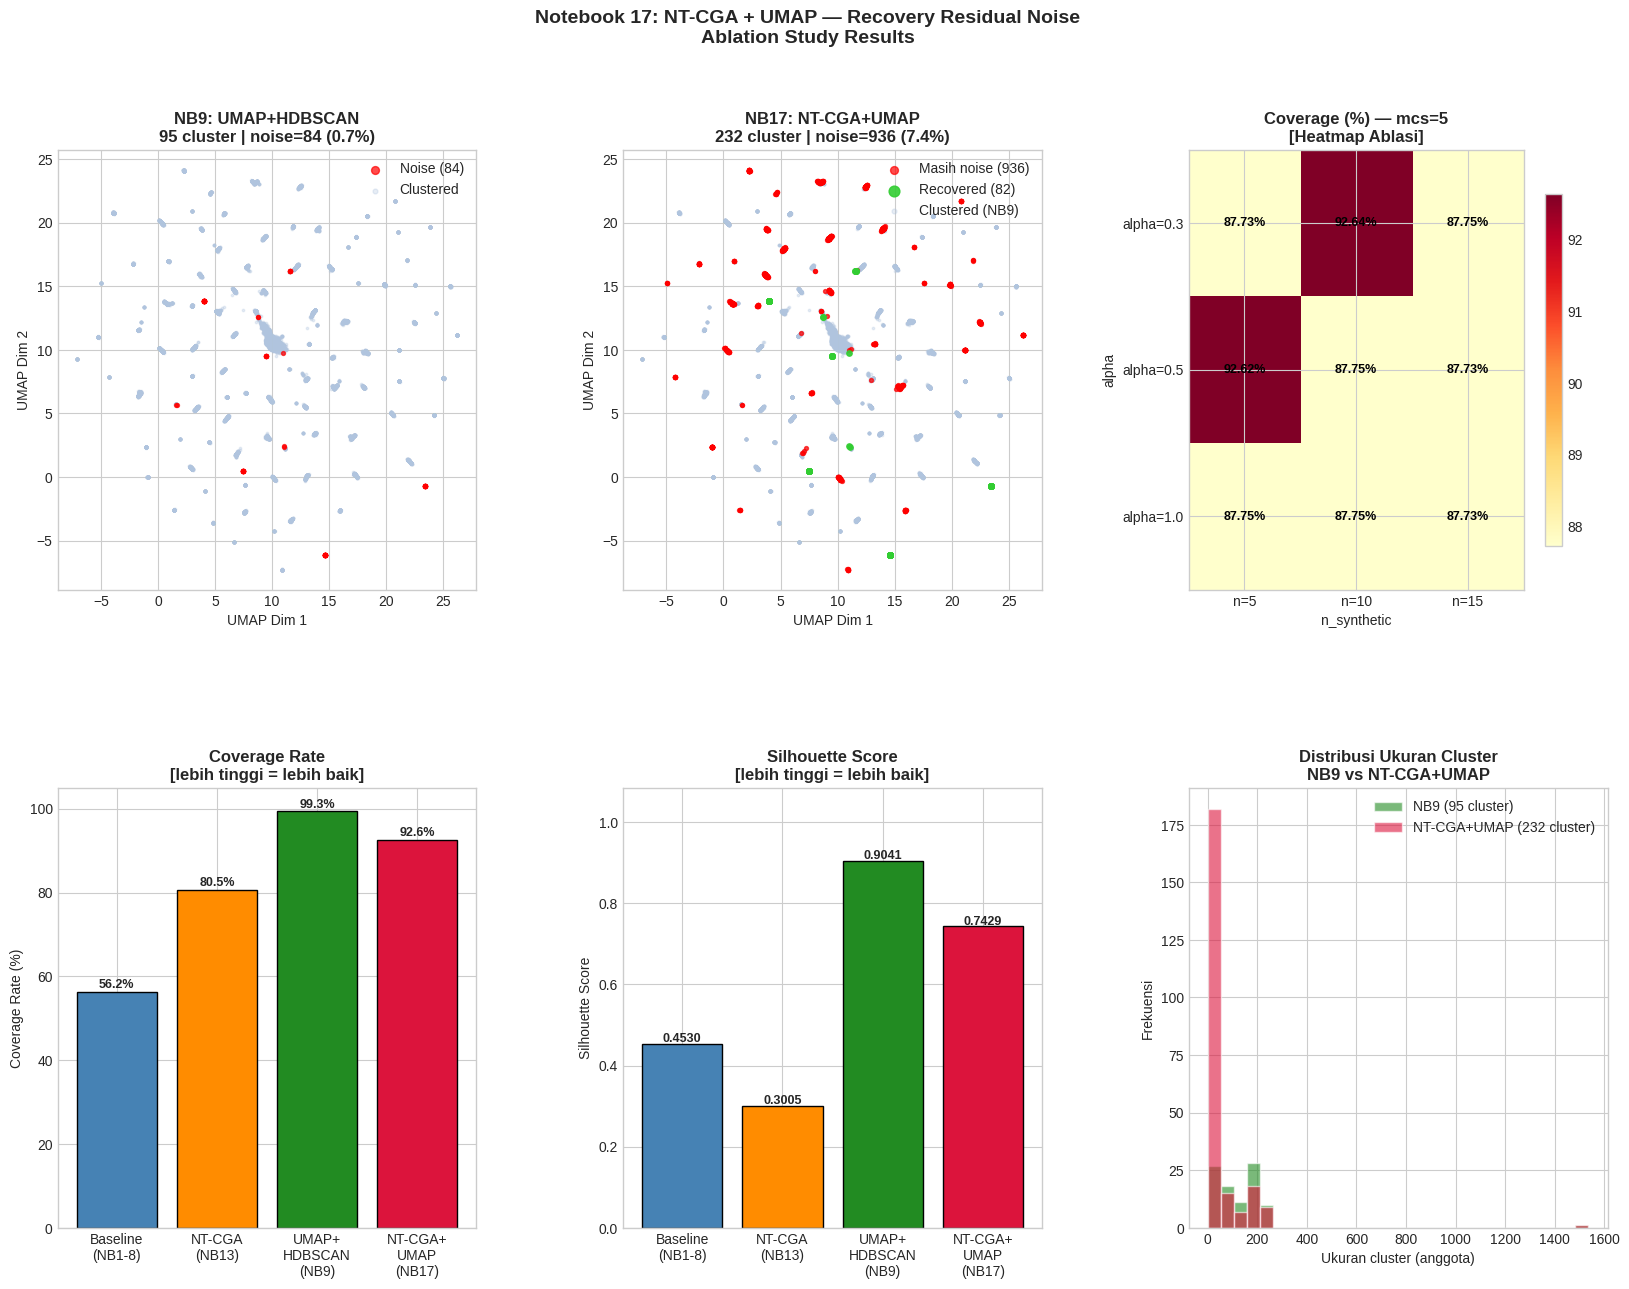

In [9]:
if len(df_valid_abl) == 0:
    print('Tidak ada hasil valid untuk divisualisasikan.')
else:
    # Buat UMAP 2D untuk visualisasi
    print('Membuat proyeksi UMAP 2D untuk visualisasi...')
    reducer_2d = umap.UMAP(
        n_components = 2,
        n_neighbors  = Config.UMAP_N_NEIGHBORS,
        metric       = Config.UMAP_METRIC,
        min_dist     = Config.UMAP_MIN_DIST,
        random_state = Config.UMAP_RANDOM_STATE,
        verbose      = False,
    )
    emb_2d = reducer_2d.fit_transform(embeddings)
    print('  Selesai')

    cmap = plt.colormaps.get_cmap('tab20')

    fig = plt.figure(figsize=(20, 14))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

    ax1 = fig.add_subplot(gs[0, 0])   # UMAP scatter NB9
    ax2 = fig.add_subplot(gs[0, 1])   # UMAP scatter NT-CGA+UMAP
    ax3 = fig.add_subplot(gs[0, 2])   # Heatmap ablation
    ax4 = fig.add_subplot(gs[1, 0])   # Bar coverage
    ax5 = fig.add_subplot(gs[1, 1])   # Bar silhouette
    ax6 = fig.add_subplot(gs[1, 2])   # Distribusi ukuran

    # --- Panel 1: Scatter NB9 ---
    mask_noise_nb9 = labels_umap == -1
    ax1.scatter(emb_2d[mask_noise_nb9, 0], emb_2d[mask_noise_nb9, 1],
                c='red', s=8, alpha=0.7, label=f'Noise ({mask_noise_nb9.sum()})', zorder=2)
    ax1.scatter(emb_2d[~mask_noise_nb9, 0], emb_2d[~mask_noise_nb9, 1],
                c='lightsteelblue', s=3, alpha=0.3, label='Clustered', zorder=1)
    ax1.set_title(f'NB9: UMAP+HDBSCAN\n{n_clusters_umap} cluster | noise={n_noise_umap} ({noise_ratio_umap:.1%})',
                  fontweight='bold')
    ax1.legend(loc='upper right', markerscale=2)
    ax1.set_xlabel('UMAP Dim 1'); ax1.set_ylabel('UMAP Dim 2')

    # --- Panel 2: Scatter NT-CGA+UMAP ---
    mask_noise_best = labels_best == -1
    mask_recovered  = (~mask_noise_nb9) & (~mask_noise_nb9)  # semua clustered di NB9 tetap
    # Points yang noise di NB9 tapi cluster di NB17
    recovered_in_best = mask_noise_nb9 & (~mask_noise_best)
    ax2.scatter(emb_2d[mask_noise_best, 0], emb_2d[mask_noise_best, 1],
                c='red', s=8, alpha=0.7, label=f'Masih noise ({mask_noise_best.sum()})', zorder=3)
    ax2.scatter(emb_2d[recovered_in_best, 0], emb_2d[recovered_in_best, 1],
                c='limegreen', s=15, alpha=0.9, label=f'Recovered ({recovered_in_best.sum()})', zorder=4)
    ax2.scatter(emb_2d[~mask_noise_nb9, 0], emb_2d[~mask_noise_nb9, 1],
                c='lightsteelblue', s=3, alpha=0.3, label='Clustered (NB9)', zorder=1)
    ax2.set_title(f'NB17: NT-CGA+UMAP\n{best_nclu} cluster | noise={best_nnoise} ({1-best_cov:.1%})',
                  fontweight='bold')
    ax2.legend(loc='upper right', markerscale=2)
    ax2.set_xlabel('UMAP Dim 1'); ax2.set_ylabel('UMAP Dim 2')

    # --- Panel 3: Heatmap ablation coverage ---
    best_mcs_val = int(best_row['mcs_recluster'])
    df_hmap = df_valid_abl[df_valid_abl['mcs_recluster'] == best_mcs_val]
    if len(df_hmap) >= 2:
        try:
            pivot = df_hmap.pivot(index='alpha', columns='n_synthetic', values='coverage') * 100
            im = ax3.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
            ax3.set_xticks(range(len(pivot.columns)))
            ax3.set_xticklabels([f'n={v}' for v in pivot.columns])
            ax3.set_yticks(range(len(pivot.index)))
            ax3.set_yticklabels([f'alpha={v}' for v in pivot.index])
            ax3.set_title(f'Coverage (%) — mcs={best_mcs_val}\n[Heatmap Ablasi]', fontweight='bold')
            ax3.set_xlabel('n_synthetic'); ax3.set_ylabel('alpha')
            for i in range(len(pivot.index)):
                for j in range(len(pivot.columns)):
                    ax3.text(j, i, f'{pivot.values[i,j]:.2f}%', ha='center', va='center',
                             color='black', fontsize=9, fontweight='bold')
            plt.colorbar(im, ax=ax3, shrink=0.8)
        except Exception:
            ax3.text(0.5, 0.5, 'Data tidak cukup\nuntuk pivot', ha='center', va='center', transform=ax3.transAxes)
    else:
        ax3.text(0.5, 0.5, 'Data tidak cukup\nuntuk heatmap', ha='center', va='center', transform=ax3.transAxes)

    # --- Panel 4: Bar coverage ---
    methods = ['Baseline\n(NB1-8)', 'NT-CGA\n(NB13)', 'UMAP+\nHDBSCAN\n(NB9)', 'NT-CGA+\nUMAP\n(NB17)']
    covs    = [56.2, 80.5, coverage_umap*100, best_cov*100]
    colors4 = ['steelblue', 'darkorange', 'forestgreen', 'crimson']
    bars4   = ax4.bar(methods, covs, color=colors4, edgecolor='black')
    ax4.set_ylabel('Coverage Rate (%)')
    ax4.set_title('Coverage Rate\n[lebih tinggi = lebih baik]', fontweight='bold')
    ax4.set_ylim(0, 105)
    for bar, val in zip(bars4, covs):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

    # --- Panel 5: Bar silhouette ---
    sils = [0.4530, 0.3005, Config.NB9_REFERENCE['silhouette'], best_sil]
    bars5 = ax5.bar(methods, sils, color=colors4, edgecolor='black')
    ax5.set_ylabel('Silhouette Score')
    ax5.set_title('Silhouette Score\n[lebih tinggi = lebih baik]', fontweight='bold')
    ax5.set_ylim(0, max(sils) * 1.2)
    for bar, val in zip(bars5, sils):
        ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

    # --- Panel 6: Distribusi ukuran cluster ---
    sizes_nb9  = [cluster_sizes_nb9[k]  for k in cluster_sizes_nb9]
    sizes_best = [cluster_sizes_best[k] for k in cluster_sizes_best]
    max_size = max(max(sizes_nb9), max(sizes_best)) if sizes_nb9 and sizes_best else 100
    bins6 = np.linspace(0, max_size + 10, 30)
    ax6.hist(sizes_nb9,  bins=bins6, alpha=0.6, label=f'NB9 ({n_clusters_umap} cluster)',
             color='forestgreen', edgecolor='white')
    ax6.hist(sizes_best, bins=bins6, alpha=0.6, label=f'NT-CGA+UMAP ({best_nclu} cluster)',
             color='crimson', edgecolor='white')
    ax6.set_xlabel('Ukuran cluster (anggota)')
    ax6.set_ylabel('Frekuensi')
    ax6.set_title('Distribusi Ukuran Cluster\nNB9 vs NT-CGA+UMAP', fontweight='bold')
    ax6.legend()

    fig.suptitle('Notebook 17: NT-CGA + UMAP — Recovery Residual Noise\nAblation Study Results',
                 fontsize=14, fontweight='bold')

    plt.tight_layout()
    plot_path = f'{Config.PLOTS_DIR}notebook17_ntcga_umap_results.png'
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f'Plot disimpan: {plot_path}')
    plt.show()

## Cell 10 — Summary & Simpan Hasil

Menyimpan seluruh hasil ke `.pkl` untuk referensi di notebook evaluasi final (NB14).

In [10]:
print('=' * 70)
print('NOTEBOOK 17 — SUMMARY NT-CGA + UMAP')
print('=' * 70)

if len(df_valid_abl) > 0:
    print(f'''
+------------------------------------------------------------------------+
|         NT-CGA + UMAP — RINGKASAN EKSPERIMEN                          |
+------------------------------------------------------------------------+
|                                                                        |
|  PIPELINE:                                                             |
|  • Embeddings asli   : {len(embeddings):,} x 512-dim (InsightFace buffalo_l)     |
|  • UMAP              : 512 -> 30 dim (cosine, n_neigh=30, min_dist=0) |
|  • HDBSCAN           : mcs=20, ms=20, eom                             |
|  • Residual noise    : {n_noise_umap} points ({noise_ratio_umap:.1%})                           |
|  • Probable singleton: {len(emb_umap_singletons)} (Q25 dari DNCN di 30-dim)               |
|                                                                        |
|  ABLATION:                                                             |
|  • alpha        : {Config.ALPHA_LIST}                               |
|  • n_synthetic  : {Config.N_SYNTHETIC_LIST}                                         |
|  • mcs_recluster: {Config.MCS_RECLUSTER}                                          |
|  • Total kombinasi : {len(ablation_results)}                                          |
|                                                                        |
|  KONFIGURASI TERBAIK:                                                  |
|  • alpha={best_alpha}, n_synthetic={best_n_syn}, mcs_recluster={best_mcs}                    |
|  • Synthetic gen: {best_syngen}                                          |
|                                                                        |
|  PERBANDINGAN HASIL:                                                   |
|  +-------------------+-----------+-----------+-----------+            |
|  | Metrik            | Baseline  | NB9       | NB17      |            |
|  |                   | (NB1-8)   | UMAP+HDBSCAN| NT-CGA  |            |
|  +-------------------+-----------+-----------+-----------+            |
|  | Clusters          | 54        | {n_clusters_umap:<9} | {best_nclu:<9} |            |
|  | Noise             | 5,565     | {n_noise_umap:<9} | {best_nnoise:<9} |            |
|  | Coverage          | 56.2%     | {coverage_umap:<9.1%} | {best_cov:<9.1%} |            |
|  | Silhouette        | 0.4530    | {Config.NB9_REFERENCE["silhouette"]:<9.4f} | {best_sil:<9.4f} |            |
|  +-------------------+-----------+-----------+-----------+            |
|                                                                        |
|  Delta NB17 vs NB9:                                                    |
|  • Delta Coverage   : {delta_cov:+.2%}                                      |
|  • Delta Clusters   : {delta_nclu:+d}                                           |
|  • Noise recovered  : {recovered} dari {n_noise_umap} ({recovered/n_noise_umap:.1%})                     |
+------------------------------------------------------------------------+
''')

    # Simpan hasil
    save_data = {
        'timestamp'              : datetime.now().isoformat(),
        'notebook'               : 'Notebook 17: NT-CGA + UMAP',
        'n_embeddings'           : len(embeddings),
        'umap_config'            : {
            'n_components' : Config.UMAP_N_COMPONENTS,
            'n_neighbors'  : Config.UMAP_N_NEIGHBORS,
            'metric'       : Config.UMAP_METRIC,
            'min_dist'     : Config.UMAP_MIN_DIST,
        },
        'hdbscan_config'         : {
            'mcs' : Config.HDBSCAN_MCS,
            'ms'  : Config.HDBSCAN_MS,
        },
        'nb9_reference'          : Config.NB9_REFERENCE,
        'n_noise_umap'           : n_noise_umap,
        'n_clustered_umap'       : len(clustered_indices),
        'n_singletons'           : len(emb_umap_singletons),
        'dncn_q25_threshold'     : float(np.percentile(
            dncn_distances, Config.DNCN_PERCENTILE)),
        'ablation_results'       : [{
            'alpha'        : r['alpha'],
            'n_synthetic'  : r['n_synthetic'],
            'mcs_recluster': r['mcs_recluster'],
            'n_syn_gen'    : r['n_syn_gen'],
            'n_clusters'   : r['n_clusters'],
            'n_noise'      : r['n_noise'],
            'coverage'     : r['coverage'],
            'silhouette'   : r['silhouette'],
            'elapsed_s'    : r['elapsed_s'],
        } for r in ablation_results],
        'best_alpha'             : best_alpha,
        'best_n_synthetic'       : best_n_syn,
        'best_mcs_recluster'     : best_mcs,
        'best_labels'            : labels_best,
        'best_coverage'          : best_cov,
        'best_silhouette'        : best_sil,
        'best_n_clusters'        : best_nclu,
        'best_n_noise'           : best_nnoise,
        'delta_coverage_vs_nb9'  : delta_cov,
        'noise_recovered'        : recovered,
        'emb_umap'               : emb_umap,
        'labels_umap_nb9'        : labels_umap,
    }

    pkl_path = f'{Config.RESULTS_DIR}notebook17_ntcga_umap_results.pkl'
    with open(pkl_path, 'wb') as f:
        pickle.dump(save_data, f)

    print(f'Hasil disimpan: {pkl_path}')

else:
    print('Tidak ada hasil valid untuk disimpan.')

print()
print('=' * 70)
print('Notebook 17 selesai.')
print('=' * 70)

NOTEBOOK 17 — SUMMARY NT-CGA + UMAP

+------------------------------------------------------------------------+
|         NT-CGA + UMAP — RINGKASAN EKSPERIMEN                          |
+------------------------------------------------------------------------+
|                                                                        |
|  PIPELINE:                                                             |
|  • Embeddings asli   : 12,715 x 512-dim (InsightFace buffalo_l)     |
|  • UMAP              : 512 -> 30 dim (cosine, n_neigh=30, min_dist=0) |
|  • HDBSCAN           : mcs=20, ms=20, eom                             |
|  • Residual noise    : 84 points (0.7%)                           |
|  • Probable singleton: 21 (Q25 dari DNCN di 30-dim)               |
|                                                                        |
|  ABLATION:                                                             |
|  • alpha        : [0.3, 0.5, 1.0]                               |
|  • n_synt